# AQSM Carrier Quality Testbench

Runs carrier-image quality checks for `r = 1`, `r = 2`, and `r = 3`, then compares each original carrier with its watermarked carrier using `PSNR` and `SSIM`.

References used inside this repo: `paper_analysis/paper_analysis.md`, `paper_analysis/aqsm_2x2_step_by_step.md`, and `paper_analysis/adaptive quantum scaling model.pdf`. Metric naming follows the scikit-image metrics API: https://scikit-image.org/docs/stable/api/skimage.metrics.html.

Note: the package implementation remains extraction-complete only for the paper's fully specified `r = 1` path. This notebook uses the paper's generic AQSM block-set counts for `r = 2` and `r = 3` carrier-quality embedding only; it does not claim `r > 1` extraction support.


In [12]:
from collections import defaultdict
from pathlib import Path
from urllib.parse import quote
from urllib.request import Request, urlopen
import math
import re

import matplotlib.pyplot as plt
import numpy as np

from aqsm_embedding import (
    AQSMBuildResult,
    AQSMWatermarkBuilder,
    BitPlaneDecomposer,
    HDWMEmbedder,
    HistogramAnalyzer,
    ImageFileLoader,
    QuantumBlockAggregator,
    ScaleParameterCalculator,
    USCSIPISampleDataset,
)

R_VALUES = (1, 2, 3)
CARRIER_SIDE = 512
BRANCH_ORDER = ("tau1=0", "tau1=1,tau2=1", "tau1=1,tau2=0")
HISTOGRAM_DENOMINATOR_MODE = "natural"
USE_DERIVED_DARK_BRANCH_VARIANTS = True
USE_PAPER_SIZE_83_CARRIER_POOL = True
SIPI_CARRIER_VOLUMES = ("misc", "aerials", "textures", "sequences")
CACHE_DIR = Path("example_outputs") / "usc_sipi_samples"
PAPER_83_CACHE_DIR = Path("example_outputs") / "usc_sipi_paper_83_carriers"

plt.rcParams["figure.dpi"] = 120


In [13]:
def branch_label(parameters):
    if parameters.tau1 == 0:
        return "tau1=0"
    return f"tau1=1,tau2={parameters.tau2}"


def invert_image(image):
    return [[255 - value for value in row] for row in image]


def print_watermark_options(title, options):
    print(title)
    for index, (key, spec) in enumerate(options.items(), start=1):
        print(f"  {index:02d}. {key:<34} {spec.image_id:<10} {spec.description}")


def print_carrier_specs(title, specs, limit=20):
    print(title)
    for index, spec in enumerate(specs[:limit], start=1):
        print(
            f"  {index:02d}. {spec['key']:<32} {spec['image_id']:<12} "
            f"{spec['volume']:<9} {spec['image_type']:<5} {spec['description']}"
        )
    if len(specs) > limit:
        print(f"  ... {len(specs) - limit} more")


def to_array(image):
    return np.asarray(image, dtype=np.float64)


def psnr(reference, test, data_range=255.0):
    reference_array = to_array(reference)
    test_array = to_array(test)
    mse = np.mean((reference_array - test_array) ** 2)
    if mse == 0:
        return math.inf
    return 10 * math.log10((data_range ** 2) / mse)


def gaussian_kernel(size=11, sigma=1.5):
    offsets = np.arange(size, dtype=np.float64) - (size // 2)
    kernel = np.exp(-(offsets ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()


def gaussian_filter(image, kernel):
    pad = len(kernel) // 2
    height, width = image.shape

    padded_x = np.pad(image, ((0, 0), (pad, pad)), mode="reflect")
    temp = np.zeros_like(image, dtype=np.float64)
    for offset, weight in enumerate(kernel):
        temp += weight * padded_x[:, offset : offset + width]

    padded_y = np.pad(temp, ((pad, pad), (0, 0)), mode="reflect")
    output = np.zeros_like(image, dtype=np.float64)
    for offset, weight in enumerate(kernel):
        output += weight * padded_y[offset : offset + height, :]
    return output


def ssim(reference, test, data_range=255.0):
    reference_array = to_array(reference)
    test_array = to_array(test)
    kernel = gaussian_kernel()

    mu_ref = gaussian_filter(reference_array, kernel)
    mu_test = gaussian_filter(test_array, kernel)

    mu_ref_sq = mu_ref * mu_ref
    mu_test_sq = mu_test * mu_test
    mu_ref_test = mu_ref * mu_test

    sigma_ref_sq = gaussian_filter(reference_array * reference_array, kernel) - mu_ref_sq
    sigma_test_sq = gaussian_filter(test_array * test_array, kernel) - mu_test_sq
    sigma_ref_test = gaussian_filter(reference_array * test_array, kernel) - mu_ref_test

    c1 = (0.01 * data_range) ** 2
    c2 = (0.03 * data_range) ** 2
    numerator = (2 * mu_ref_test + c1) * (2 * sigma_ref_test + c2)
    denominator = (mu_ref_sq + mu_test_sq + c1) * (sigma_ref_sq + sigma_test_sq + c2)
    return float(np.mean(numerator / denominator))


def aggregate_blocks(blocks, levels, aggregator):
    current_blocks = list(blocks)
    for _ in range(levels):
        if len(current_blocks) % 4:
            raise ValueError("QBA input block count must be divisible by 4.")
        current_blocks = [
            aggregator.aggregate_four(*current_blocks[index : index + 4])
            for index in range(0, len(current_blocks), 4)
        ]
    return current_blocks


def build_aqsm_for_carrier_quality(bit_planes, scale_parameters, r1_builder, aggregator):
    if scale_parameters.scale_factor == 1:
        return r1_builder.build(bit_planes, scale_parameters)

    low_half_set = [bit_planes[f"w{i}"] for i in range(1, 5)]
    high_half_set = [bit_planes[f"w{i}"] for i in range(5, 9)]
    block_sets = [low_half_set for _ in range(scale_parameters.alpha)]
    block_sets += [high_half_set for _ in range(scale_parameters.alpha + 2)]
    input_blocks = [block for block_set in block_sets for block in block_set]
    embedded_watermarks = aggregate_blocks(
        input_blocks,
        levels=scale_parameters.aggregation_level,
        aggregator=aggregator,
    )
    return AQSMBuildResult(
        embedded_watermarks=embedded_watermarks,
        declared_output_count=scale_parameters.q_outputs,
    )


def show_carrier_result(record):
    fig, axes = plt.subplots(1, 3, figsize=(8.2, 2.8))
    images = (
        record["watermark_image"],
        record["carrier_image"],
        record["watermarked_carrier"],
    )
    titles = (
        f"Watermark\n{record['watermark_key']}",
        f"Original carrier\n{record['carrier_key']}",
        f"Watermarked carrier\nPSNR {record['psnr']:.3f} dB | SSIM {record['ssim']:.6f}",
    )
    for axis, image, title in zip(axes, images, titles):
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
        axis.set_title(title, fontsize=8)
        axis.axis("off")
    fig.suptitle(f"r={record['r']} | {record['branch']}", fontsize=9)
    plt.tight_layout()
    plt.show()


In [14]:
def make_key(volume, image_id):
    return f"{volume}_{re.sub(r'[^A-Za-z0-9]+', '_', image_id).strip('_')}"


def parse_sipi_volume_512_specs(volume):
    url = f"https://sipi.usc.edu/database/?volume={volume}"
    request = Request(url, headers={"User-Agent": "AQSM-demo/1.0"})
    html = urlopen(request, timeout=60).read().decode("utf-8", errors="replace")
    pre_block = html.split("<PRE>", 1)[1].split("</PRE>", 1)[0]

    specs = []
    for line in pre_block.splitlines():
        clean_line = re.sub(r"<[^>]+>", "", line).replace("&amp;", "&").strip()
        match = re.match(r"^(\S+)\s+(.+?)\s+(\d+)\s+(Color|Gray|Mono)\s*$", clean_line)
        if not match:
            continue
        image_id, description, side, image_type = match.groups()
        if int(side) != CARRIER_SIDE:
            continue
        specs.append({
            "key": make_key(volume, image_id),
            "volume": volume,
            "image_id": image_id,
            "description": description,
            "side": int(side),
            "image_type": image_type,
        })
    return specs


def build_paper_size_83_carrier_specs():
    specs = []
    counts_by_volume = {}
    for volume in SIPI_CARRIER_VOLUMES:
        volume_specs = parse_sipi_volume_512_specs(volume)
        counts_by_volume[volume] = len(volume_specs)
        specs.extend(volume_specs)
    if len(specs) != 83:
        raise RuntimeError(f"Expected 83 USC-SIPI 512x512 carrier specs, got {len(specs)}.")
    return specs, counts_by_volume


def download_sipi_spec(spec, cache_directory):
    cache_directory.mkdir(parents=True, exist_ok=True)
    output_path = cache_directory / f"{spec['key']}.tiff"
    if output_path.exists():
        return output_path
    image_id = quote(spec["image_id"], safe="")
    volume = quote(spec["volume"], safe="")
    url = f"https://sipi.usc.edu/database/download.php?img={image_id}&vol={volume}"
    request = Request(url, headers={"User-Agent": "AQSM-demo/1.0"})
    with urlopen(request, timeout=60) as response:
        output_path.write_bytes(response.read())
    return output_path


In [15]:
dataset = USCSIPISampleDataset(CACHE_DIR)
watermark_options = dataset.watermark_options()

if USE_PAPER_SIZE_83_CARRIER_POOL:
    carrier_specs, counts_by_volume = build_paper_size_83_carrier_specs()
    carrier_paths = {
        spec["key"]: download_sipi_spec(spec, PAPER_83_CACHE_DIR)
        for spec in carrier_specs
    }
    print("Using the USC-SIPI 83-image 512x512 carrier pool.")
    print("This matches the paper's reported carrier count, but the paper does not publish the exact IDs.")
    print(f"Carrier count: {len(carrier_specs)}")
    for volume, count in counts_by_volume.items():
        print(f"  {volume:<9} {count:>2}")
else:
    static_options = dataset.carrier_options()
    carrier_specs = [
        {
            "key": key,
            "volume": "misc",
            "image_id": spec.image_id,
            "description": spec.description,
            "side": spec.side,
            "image_type": spec.image_type,
        }
        for key, spec in static_options.items()
    ]
    carrier_paths = {spec["key"]: dataset.download_sample(spec["key"]) for spec in carrier_specs}
    print(f"Using the smaller configured carrier pool: {len(carrier_specs)}")

print()
print_watermark_options("Watermark source options:", watermark_options)
print()
print_carrier_specs("Carrier pool preview:", carrier_specs)


Using the USC-SIPI 83-image 512x512 carrier pool.
This matches the paper's reported carrier count, but the paper does not publish the exact IDs.
Carrier count: 83
  misc      22
  aerials   12
  textures  39
  sequences 10

Watermark source options:
  01. watermark_moon_256                 5.1.09     Moon surface, 256x256 grayscale
  02. watermark_aerial_256               5.1.10     Aerial, 256x256 grayscale
  03. watermark_airplane_256             5.1.11     Airplane, 256x256 grayscale
  04. watermark_clock_256                5.1.12     Clock, 256x256 grayscale
  05. watermark_resolution_chart_256     5.1.13     Resolution chart, 256x256 grayscale
  06. watermark_chemical_plant_256       5.1.14     Chemical plant, 256x256 grayscale

Carrier pool preview:
  01. misc_4_2_01                      4.2.01       misc      Color Splash
  02. misc_4_2_03                      4.2.03       misc      Color Mandrill (a.k.a. Baboon)
  03. misc_4_2_05                      4.2.05       misc      Colo

In [16]:
loader = ImageFileLoader()
watermark_paths = {key: dataset.download_sample(key) for key in watermark_options}

watermarks_by_r = {}
for r in R_VALUES:
    watermark_side = CARRIER_SIDE // (2 ** r)
    watermarks_by_r[r] = {
        key: loader.load_grayscale(path, target_side=watermark_side)
        for key, path in watermark_paths.items()
    }

print(f"Carrier paths ready: {len(carrier_paths)}")
for r in R_VALUES:
    print(f"Loaded {len(watermarks_by_r[r])} watermark sources at r={r}, side={CARRIER_SIDE // (2 ** r)}.")


Carrier paths ready: 83
Loaded 6 watermark sources at r=1, side=256.
Loaded 6 watermark sources at r=2, side=128.
Loaded 6 watermark sources at r=3, side=64.


In [17]:
histogram_analyzer = HistogramAnalyzer()
scale_calculator = ScaleParameterCalculator()
first_carrier_path = carrier_paths[carrier_specs[0]["key"]]
reference_carrier = loader.load_grayscale(first_carrier_path, target_side=CARRIER_SIDE)


def analyze_variant(r, key, source_key, description, image, variant_kind):
    scale_parameters = scale_calculator.compute(image, reference_carrier)
    histogram_parameters = histogram_analyzer.analyze(
        image,
        scale_parameters,
        denominator_mode=HISTOGRAM_DENOMINATOR_MODE,
    )
    return {
        "r": r,
        "key": key,
        "source_key": source_key,
        "description": description,
        "variant_kind": variant_kind,
        "image": image,
        "histogram_parameters": histogram_parameters,
        "branch": branch_label(histogram_parameters),
    }


selected_watermarks = {}
for r in R_VALUES:
    variants = []
    for key, image in watermarks_by_r[r].items():
        variants.append(
            analyze_variant(
                r=r,
                key=key,
                source_key=key,
                description=watermark_options[key].description,
                image=image,
                variant_kind="natural",
            )
        )

    if USE_DERIVED_DARK_BRANCH_VARIANTS:
        for variant in list(variants):
            variants.append(
                analyze_variant(
                    r=r,
                    key=f"inverted_{variant['source_key']}",
                    source_key=variant["source_key"],
                    description=f"Inverted {variant['description']}",
                    image=invert_image(variant["image"]),
                    variant_kind="derived_inverted",
                )
            )

    by_branch = defaultdict(list)
    for variant in variants:
        by_branch[variant["branch"]].append(variant)

    selected_watermarks[r] = {}
    print(f"r={r} branch coverage:")
    for branch in BRANCH_ORDER:
        available = by_branch.get(branch, [])
        if not available:
            print(f"  {branch:<13} none")
            continue
        selected = available[0]
        selected_watermarks[r][branch] = selected
        print(
            f"  {branch:<13} selected {selected['key']} "
            f"({selected['variant_kind']}, T_dark={selected['histogram_parameters'].t_dark:.4f}, "
            f"T_bright={selected['histogram_parameters'].t_bright:.4f})"
        )
    print()


r=1 branch coverage:
  tau1=0        selected watermark_moon_256 (natural, T_dark=0.4448, T_bright=0.5552)
  tau1=1,tau2=1 selected watermark_airplane_256 (natural, T_dark=0.0366, T_bright=0.9634)
  tau1=1,tau2=0 selected inverted_watermark_airplane_256 (derived_inverted, T_dark=0.9634, T_bright=0.0366)

r=2 branch coverage:
  tau1=0        selected watermark_moon_256 (natural, T_dark=0.4351, T_bright=0.5649)
  tau1=1,tau2=1 selected watermark_airplane_256 (natural, T_dark=0.0399, T_bright=0.9601)
  tau1=1,tau2=0 selected inverted_watermark_airplane_256 (derived_inverted, T_dark=0.9601, T_bright=0.0399)

r=3 branch coverage:
  tau1=0        selected watermark_moon_256 (natural, T_dark=0.4331, T_bright=0.5669)
  tau1=1,tau2=1 selected watermark_airplane_256 (natural, T_dark=0.0410, T_bright=0.9590)
  tau1=1,tau2=0 selected inverted_watermark_airplane_256 (derived_inverted, T_dark=0.9590, T_bright=0.0410)



In [18]:
bit_plane_decomposer = BitPlaneDecomposer()
r1_aqsm_builder = AQSMWatermarkBuilder()
aggregator = QuantumBlockAggregator()
hdwm_embedder = HDWMEmbedder()


def embed_for_carrier_quality(watermark_image, carrier_image):
    scale_parameters = scale_calculator.compute(watermark_image, carrier_image)
    histogram_parameters = histogram_analyzer.analyze(
        watermark_image,
        scale_parameters,
        denominator_mode=HISTOGRAM_DENOMINATOR_MODE,
    )
    bit_planes = bit_plane_decomposer.decompose(watermark_image)
    aqsm_result = build_aqsm_for_carrier_quality(
        bit_planes,
        scale_parameters,
        r1_builder=r1_aqsm_builder,
        aggregator=aggregator,
    )
    embedding_result = hdwm_embedder.embed(
        carrier_image=carrier_image,
        aqsm_result=aqsm_result,
        histogram_parameters=histogram_parameters,
        scale_parameters=scale_parameters,
    )
    return scale_parameters, histogram_parameters, aqsm_result, embedding_result


records = []
display_records = []
for r in R_VALUES:
    for branch in BRANCH_ORDER:
        if branch not in selected_watermarks[r]:
            continue
        watermark = selected_watermarks[r][branch]
        displayed_this_group = False
        for carrier_index, spec in enumerate(carrier_specs, start=1):
            carrier_image = loader.load_grayscale(carrier_paths[spec["key"]], target_side=CARRIER_SIDE)
            scale_parameters, histogram_parameters, aqsm_result, embedding_result = embed_for_carrier_quality(
                watermark["image"],
                carrier_image,
            )
            watermarked_carrier = embedding_result.final_image
            record = {
                "r": r,
                "branch": branch,
                "watermark_key": watermark["key"],
                "watermark_variant_kind": watermark["variant_kind"],
                "carrier_key": spec["key"],
                "carrier_image_id": spec["image_id"],
                "carrier_volume": spec["volume"],
                "scale_factor": scale_parameters.scale_factor,
                "embedded_aqsm_images": len(aqsm_result.embedded_watermarks),
                "psnr": psnr(carrier_image, watermarked_carrier),
                "ssim": ssim(carrier_image, watermarked_carrier),
            }
            records.append(record)
            if not displayed_this_group:
                display_records.append({
                    **record,
                    "watermark_image": watermark["image"],
                    "carrier_image": carrier_image,
                    "watermarked_carrier": watermarked_carrier,
                })
                displayed_this_group = True
        print(f"Completed r={r}, {branch}: {len(carrier_specs)} carriers")

print(f"Total carrier-quality runs: {len(records)}")


Completed r=1, tau1=0: 83 carriers
Completed r=1, tau1=1,tau2=1: 83 carriers
Completed r=1, tau1=1,tau2=0: 83 carriers
Completed r=2, tau1=0: 83 carriers
Completed r=2, tau1=1,tau2=1: 83 carriers
Completed r=2, tau1=1,tau2=0: 83 carriers
Completed r=3, tau1=0: 83 carriers
Completed r=3, tau1=1,tau2=1: 83 carriers
Completed r=3, tau1=1,tau2=0: 83 carriers
Total carrier-quality runs: 747


In [19]:
def summarize(records_subset):
    psnr_values = [record["psnr"] for record in records_subset]
    ssim_values = [record["ssim"] for record in records_subset]
    return {
        "count": len(records_subset),
        "avg_psnr": sum(psnr_values) / len(psnr_values),
        "min_psnr": min(psnr_values),
        "max_psnr": max(psnr_values),
        "avg_ssim": sum(ssim_values) / len(ssim_values),
        "min_ssim": min(ssim_values),
        "max_ssim": max(ssim_values),
    }


print("Carrier quality summary:")
print("r branch         carriers aqsm_imgs avg_psnr min_psnr max_psnr avg_ssim  min_ssim  max_ssim")
for r in R_VALUES:
    for branch in BRANCH_ORDER:
        subset = [record for record in records if record["r"] == r and record["branch"] == branch]
        if not subset:
            continue
        summary = summarize(subset)
        aqsm_images = subset[0]["embedded_aqsm_images"]
        print(
            f"{r:<1} {branch:<13} {summary['count']:>8} {aqsm_images:>9} "
            f"{summary['avg_psnr']:>8.3f} {summary['min_psnr']:>8.3f} {summary['max_psnr']:>8.3f} "
            f"{summary['avg_ssim']:>8.6f} {summary['min_ssim']:>8.6f} {summary['max_ssim']:>8.6f}"
        )


Carrier quality summary:
r branch         carriers aqsm_imgs avg_psnr min_psnr max_psnr avg_ssim  min_ssim  max_ssim
1 tau1=0              83         3   39.135   36.353   39.752 0.975547 0.930796 0.999099
1 tau1=1,tau2=1       83         3   37.689   35.545   39.359 0.974586 0.936462 0.998673
1 tau1=1,tau2=0       83         3   37.689   35.545   39.359 0.974586 0.936462 0.998673
2 tau1=0              83         1   51.138   51.014   51.276 0.998137 0.994842 0.999942
2 tau1=1,tau2=1       83         1   51.179   50.562   51.992 0.998301 0.995417 0.999940
2 tau1=1,tau2=0       83         1   51.179   50.562   51.992 0.998301 0.995417 0.999940
3 tau1=0              83         1   51.145   51.054   51.303 0.997986 0.994419 0.999939
3 tau1=1,tau2=1       83         1   51.159   50.737   51.512 0.998063 0.994747 0.999936
3 tau1=1,tau2=0       83         1   51.159   50.737   51.512 0.998063 0.994747 0.999936


In [20]:
PAPER_PSNR_MEANS = {
    1: 36.78,
    2: 51.25,
    3: 51.15,
}

print("Overall PSNR means compared with the paper:")
print("r   notebook_mean_dB  paper_mean_dB  difference_dB  difference_%")
for r in R_VALUES:
    subset = [record for record in records if record["r"] == r]
    mean_psnr = sum(record["psnr"] for record in subset) / len(subset)
    paper_mean = PAPER_PSNR_MEANS[r]
    difference = mean_psnr - paper_mean
    difference_percent = 100 * difference / paper_mean
    print(
        f"{r:<1} {mean_psnr:>18.3f} {paper_mean:>14.3f} "
        f"{difference:>14.3f} {difference_percent:>12.2f}"
    )


Overall PSNR means compared with the paper:
r   notebook_mean_dB  paper_mean_dB  difference_dB  difference_%
1             38.171         36.780          1.391         3.78
2             51.166         51.250         -0.084        -0.16
3             51.154         51.150          0.004         0.01


In [21]:
PAPER_SSIM_MEANS = {
    1: 0.9693,
    2: 0.9982,
    3: 0.9981,
}

print("Overall SSIM means compared with the paper:")
print("r   notebook_mean  paper_mean  difference  squared_difference")
for r in R_VALUES:
    subset = [record for record in records if record["r"] == r]
    mean_ssim = sum(record["ssim"] for record in subset) / len(subset)
    paper_mean = PAPER_SSIM_MEANS[r]
    difference = mean_ssim - paper_mean
    squared_difference = difference ** 2
    print(
        f"{r:<1} {mean_ssim:>15.6f} {paper_mean:>11.6f} "
        f"{difference:>11.6f} {squared_difference:>19.10f}"
    )


Overall SSIM means compared with the paper:
r   notebook_mean  paper_mean  difference  squared_difference
1        0.974906    0.969300    0.005606        0.0000314300
2        0.998246    0.998200    0.000046        0.0000000021
3        0.998037    0.998100   -0.000063        0.0000000039


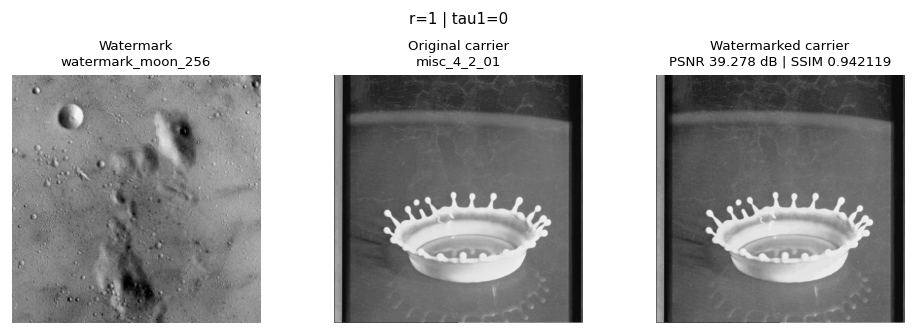

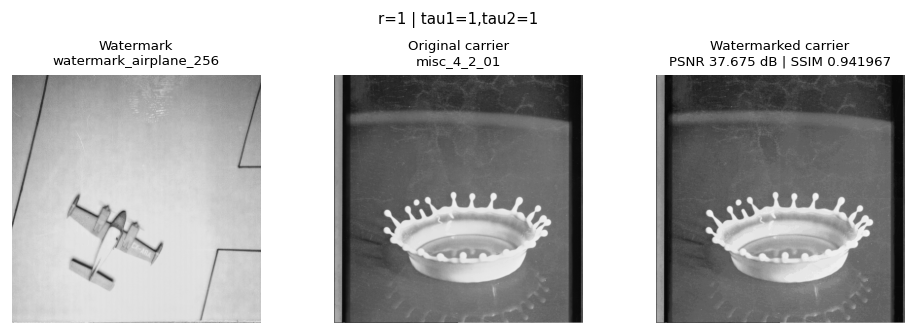

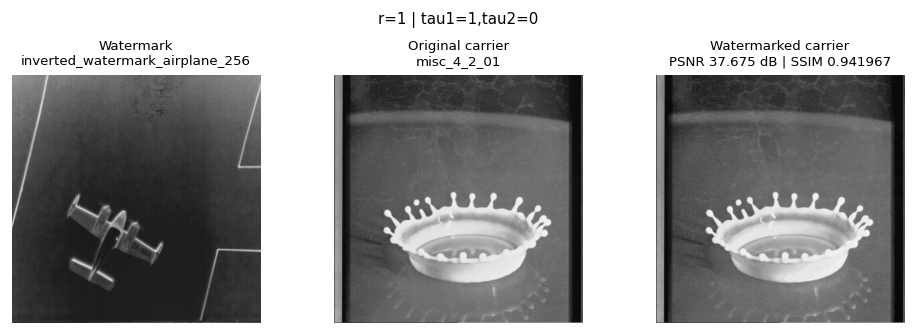

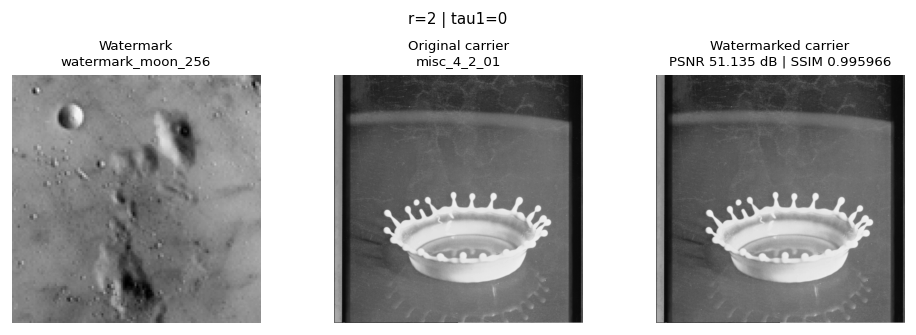

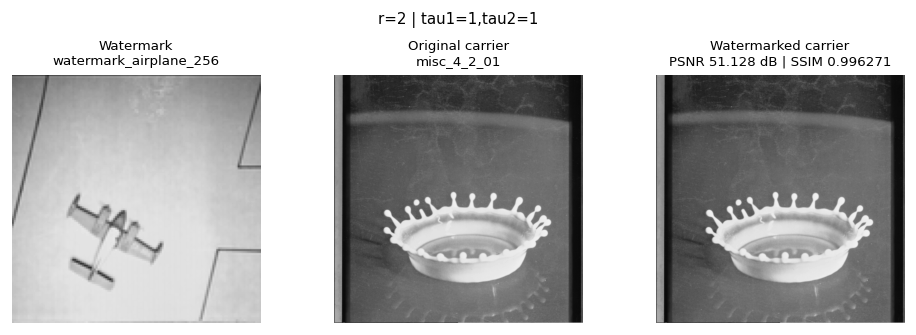

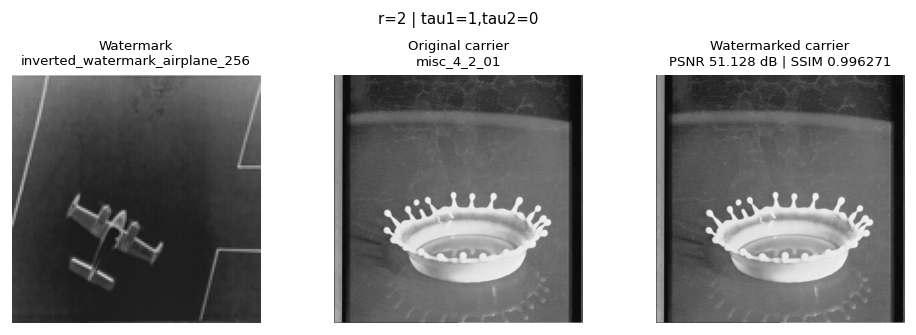

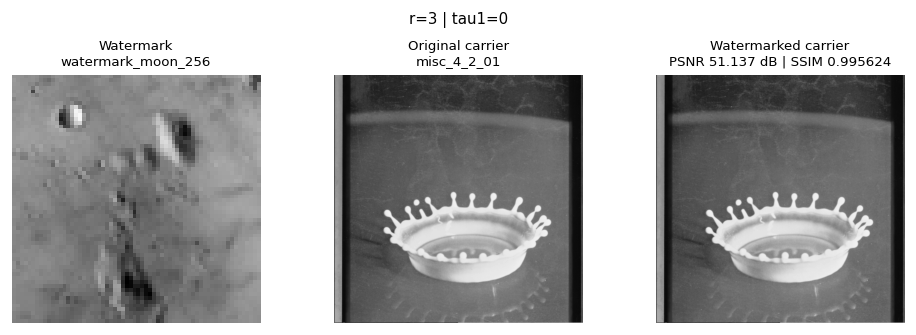

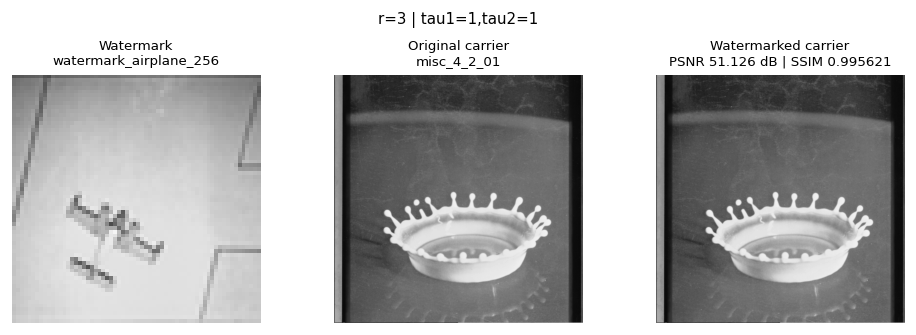

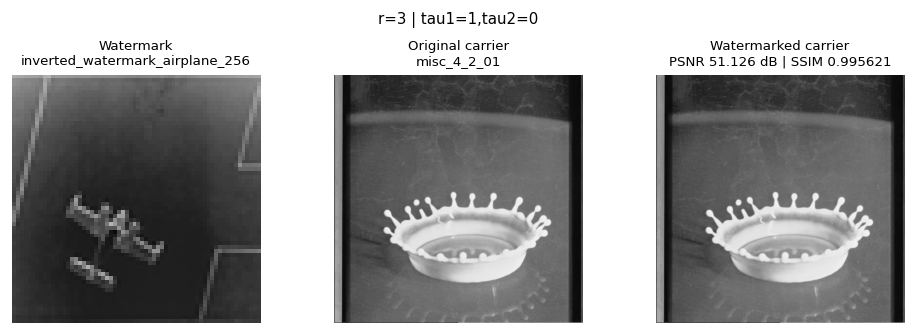

In [22]:
for record in display_records:
    show_carrier_result(record)


In [23]:
print("Paper visual-quality reference means from paper_analysis/paper_analysis.md:")
print("  r=1: PSNR 36.78 dB, SSIM 0.9693")
print("  r=2: PSNR 51.25 dB, SSIM 0.9982")
print("  r=3: PSNR 51.15 dB, SSIM 0.9981")
print()
print("This notebook uses USC-SIPI watermark sources instead of the paper's unavailable Elsevier watermark image.")
print("The carrier pool uses all currently listed non-rotated 512x512 images from USC-SIPI Miscellaneous, Aerials, Textures, and Sequences, giving the same 83-image count reported by the paper.")


Paper visual-quality reference means from paper_analysis/paper_analysis.md:
  r=1: PSNR 36.78 dB, SSIM 0.9693
  r=2: PSNR 51.25 dB, SSIM 0.9982
  r=3: PSNR 51.15 dB, SSIM 0.9981

This notebook uses USC-SIPI watermark sources instead of the paper's unavailable Elsevier watermark image.
The carrier pool uses all currently listed non-rotated 512x512 images from USC-SIPI Miscellaneous, Aerials, Textures, and Sequences, giving the same 83-image count reported by the paper.
